In [ ]:
# ShopRocket Operations Analytics
## Notebook 4 — Demand Forecasting

**Objective:** Forecast next 30 days demand for top SKUs using Facebook Prophet with Indian festive season effects.

**Author:** Sadique Shoaib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

print("✅ Libraries loaded!")
print("Prophet ready hai!")

Importing plotly failed. Interactive plots will not work.


✅ Libraries loaded!
Prophet ready hai!


In [2]:
# ── Data load 
SAVE_PATH = 'C:/Users/Sadique/OneDrive/Desktop/ShopRocket-ops-Analytics/data/processed/'

orders      = pd.read_csv(SAVE_PATH + 'orders_enriched.csv',
                          parse_dates=['order_purchase_timestamp'])
order_items = pd.read_csv(SAVE_PATH + 'order_items.csv')

print("✅ Data loaded!")
print(f"Orders     : {orders.shape}")
print(f"Order Items: {order_items.shape}")

✅ Data loaded!
Orders     : (99441, 13)
Order Items: (112650, 8)


In [ ]:
## Step 1 — Daily Demand Time Series
Har product ki daily units sold nikalo

In [3]:
# ── Orders + Items join karo ───────────────────────────
orders_items = order_items.merge(
    orders[['order_id', 'order_purchase_timestamp']],
    on='order_id',
    how='left'
)

# ── Date column clean karo ─────────────────────────────
orders_items['date'] = pd.to_datetime(
    orders_items['order_purchase_timestamp']
).dt.date

# ── Daily demand per product ───────────────────────────
daily_demand = (
    orders_items
    .groupby(['date', 'product_id'])
    ['order_item_id']
    .count()
    .reset_index()
)
daily_demand.columns = ['date', 'product_id', 'units_sold']
daily_demand['date'] = pd.to_datetime(daily_demand['date'])

print(f"✅ Daily demand ready: {daily_demand.shape}")
print(f"\nSample:")
print(daily_demand.head(8))

✅ Daily demand ready: (94591, 3)

Sample:
        date                        product_id  units_sold
0 2016-09-04  c1488892604e4ba5cff5b4eb4d595400           1
1 2016-09-04  f293394c72c9b5fafd7023301fc21fc2           1
2 2016-09-05  f3c2d01a84c947b078e32bbef0718962           1
3 2016-09-15  5a6b04657a4c5ee34285d1e4619a96b4           3
4 2016-10-02  d2998d7ced12f83f9b832f33cf6507b6           1
5 2016-10-03  107177bf61755f05c604fe57e02467d6           1
6 2016-10-03  3ae08df6bcbfe23586dd431c40bddbb7           1
7 2016-10-03  9c7bdf67b06b419aefb93cfdfc96c55d           1


In [ ]:
## Step 2 — Top SKUs by Volume
Sabse zyada bikne wale products identify karo


In [4]:
# ── Top 10 products by total units sold ────────────────
top_skus = (
    daily_demand
    .groupby('product_id')
    ['units_sold']
    .sum()
    .reset_index()
    .sort_values('units_sold', ascending=False)
    .head(10)
)
top_skus.columns = ['product_id', 'total_units']
top_skus['rank'] = range(1, 11)

print("=" * 55)
print("TOP 10 SKUs BY VOLUME")
print("=" * 55)
print(top_skus[['rank', 'product_id', 'total_units']])

# Top SKU select karo forecasting ke liye
top_sku_id = top_skus.iloc[0]['product_id']
print(f"\n🎯 Forecasting karenge is SKU pe:")
print(f"   {top_sku_id}")
print(f"   Total units sold: {top_skus.iloc[0]['total_units']}")

TOP 10 SKUs BY VOLUME
       rank                        product_id  total_units
22112     1  aca2eb7d00ea1a7b8ebd4e68314663af          527
19742     2  99a4788cb24856965c36a24e339b6058          488
8613      3  422879e10f46682990de24d770e7f83d          484
7364      4  389d119b48cf3043d311335e499d9c6b          392
7079      5  368c6c730842d78016ad823897a372db          388
10840     6  53759a2ecddad2bb87a079a1f1519f73          373
27039     7  d1c427060a0f73f6b889a5c7c61f2ac4          343
10867     8  53b36df67ebb7c41585e8d54d6772e08          323
2794      9  154e7e31ebfa092203795c972e5804a6          281
8051     10  3dd2a17168ec895c781a9191c1e95ad7          274

🎯 Forecasting karenge is SKU pe:
   aca2eb7d00ea1a7b8ebd4e68314663af
   Total units sold: 527


In [ ]:
## Step 3 — Top SKU Time Series Prepare karo
Prophet ke liye data format karna

In [5]:
# ── Top SKU ka daily demand nikalo ─────────────────────
sku_df = (
    daily_demand[daily_demand['product_id'] == top_sku_id]
    .copy()
    .sort_values('date')
)

# ── Prophet format chahiye: ds aur y columns ───────────
# ds = date, y = value (Prophet ka rule hai yeh!)
sku_df = sku_df.rename(columns={
    'date'      : 'ds',
    'units_sold': 'y'
})

# ── Missing dates fill karo with 0 ─────────────────────
# Jis din koi order nahi aaya, woh din missing hai
# Prophet ko complete date range chahiye!
date_range = pd.date_range(
    start=sku_df['ds'].min(),
    end=sku_df['ds'].max(),
    freq='D'
)
sku_df = (
    sku_df
    .set_index('ds')
    .reindex(date_range)
    .fillna(0)
    .reset_index()
    .rename(columns={'index': 'ds'})
)
sku_df = sku_df[['ds', 'y']]

print(f"✅ Time series ready!")
print(f"Date range : {sku_df['ds'].min()} → {sku_df['ds'].max()}")
print(f"Total days : {len(sku_df)}")
print(f"Days with orders : {(sku_df['y'] > 0).sum()}")
print(f"Days with 0 orders: {(sku_df['y'] == 0).sum()}")
print(f"\nSample:")
print(sku_df.head(8))

✅ Time series ready!
Date range : 2017-07-25 00:00:00 → 2018-08-18 00:00:00
Total days : 390
Days with orders : 171
Days with 0 orders: 219

Sample:
          ds    y
0 2017-07-25  1.0
1 2017-07-26  0.0
2 2017-07-27  0.0
3 2017-07-28  2.0
4 2017-07-29  2.0
5 2017-07-30  0.0
6 2017-07-31  0.0
7 2017-08-01  3.0


In [ ]:
## Step 4 — Prophet Forecasting Model
Facebook Prophet se 30 din ka forecast banao

In [6]:
# ── Train/Test Split ───────────────────────────────────
# Last 30 days = test (actual values hain hamare paas)
# Baaki sab = train (model yahi seekhega)

train = sku_df[:-30].copy()
test  = sku_df[-30:].copy()

print(f"Train : {train['ds'].min()} → {train['ds'].max()} ({len(train)} days)")
print(f"Test  : {test['ds'].min()} → {test['ds'].max()} ({len(test)} days)")

# ── Prophet Model ──────────────────────────────────────
m = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

# ── Indian/Brazilian Festive Season add karo ───────────
# Black Friday Brazil = November
# Yeh custom holiday hai jo hum manually add kar rahe hain!
m.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=5
)

# ── Model train karo ───────────────────────────────────
print("\nTraining model...")
m.fit(train)
print("✅ Model trained!")

Train : 2017-07-25 00:00:00 → 2018-07-19 00:00:00 (360 days)
Test  : 2018-07-20 00:00:00 → 2018-08-18 00:00:00 (30 days)


02:27:45 - cmdstanpy - INFO - Chain [1] start processing



Training model...


02:27:46 - cmdstanpy - INFO - Chain [1] done processing


✅ Model trained!


In [13]:
# ── Manually 30 future dates banao ────────────────────
last_date = sku_df['ds'].max()

# History + 30 new days manually
future_dates = pd.date_range(
    start=sku_df['ds'].min(),
    periods=len(sku_df) + 30,
    freq='D'
)
future = pd.DataFrame({'ds': future_dates})

print(f"Dataset end  : {last_date.date()}")
print(f"Forecast end : {future['ds'].max().date()}")
print(f"Total rows   : {len(future)}")

# ── Forecast karo ─────────────────────────────────────
forecast = m.predict(future)

# ── Sirf naye 30 din dikhao ───────────────────────────
future_only = forecast[forecast['ds'] > last_date].copy()
future_only['yhat'] = future_only['yhat'].clip(lower=0).round(1)
future_only['yhat_lower'] = future_only['yhat_lower'].clip(lower=0).round(1)
future_only['yhat_upper'] = future_only['yhat_upper'].clip(lower=0).round(1)

print(f"\n✅ Next 30 days forecast:")
print(future_only[['ds', 'yhat', 
                   'yhat_lower',
                   'yhat_upper']].to_string(index=False))

Dataset end  : 2018-08-18
Forecast end : 2018-09-17
Total rows   : 420

✅ Next 30 days forecast:
        ds  yhat  yhat_lower  yhat_upper
2018-08-19   1.0         0.0         2.9
2018-08-20   1.2         0.0         3.3
2018-08-21   1.0         0.0         2.7
2018-08-22   0.7         0.0         2.7
2018-08-23   1.1         0.0         3.2
2018-08-24   0.8         0.0         2.7
2018-08-25   0.0         0.0         1.7
2018-08-26   0.0         0.0         1.1
2018-08-27   0.0         0.0         1.5
2018-08-28   0.0         0.0         1.6
2018-08-29   0.0         0.0         1.5
2018-08-30   0.0         0.0         2.0
2018-08-31   0.0         0.0         1.9
2018-09-01   0.0         0.0         0.9
2018-09-02   0.0         0.0         0.9
2018-09-03   0.0         0.0         1.7
2018-09-04   0.5         0.0         2.7
2018-09-05   0.9         0.0         2.9
2018-09-06   1.6         0.0         3.6
2018-09-07   1.3         0.0         3.5
2018-09-08   0.2         0.0         2.2
2

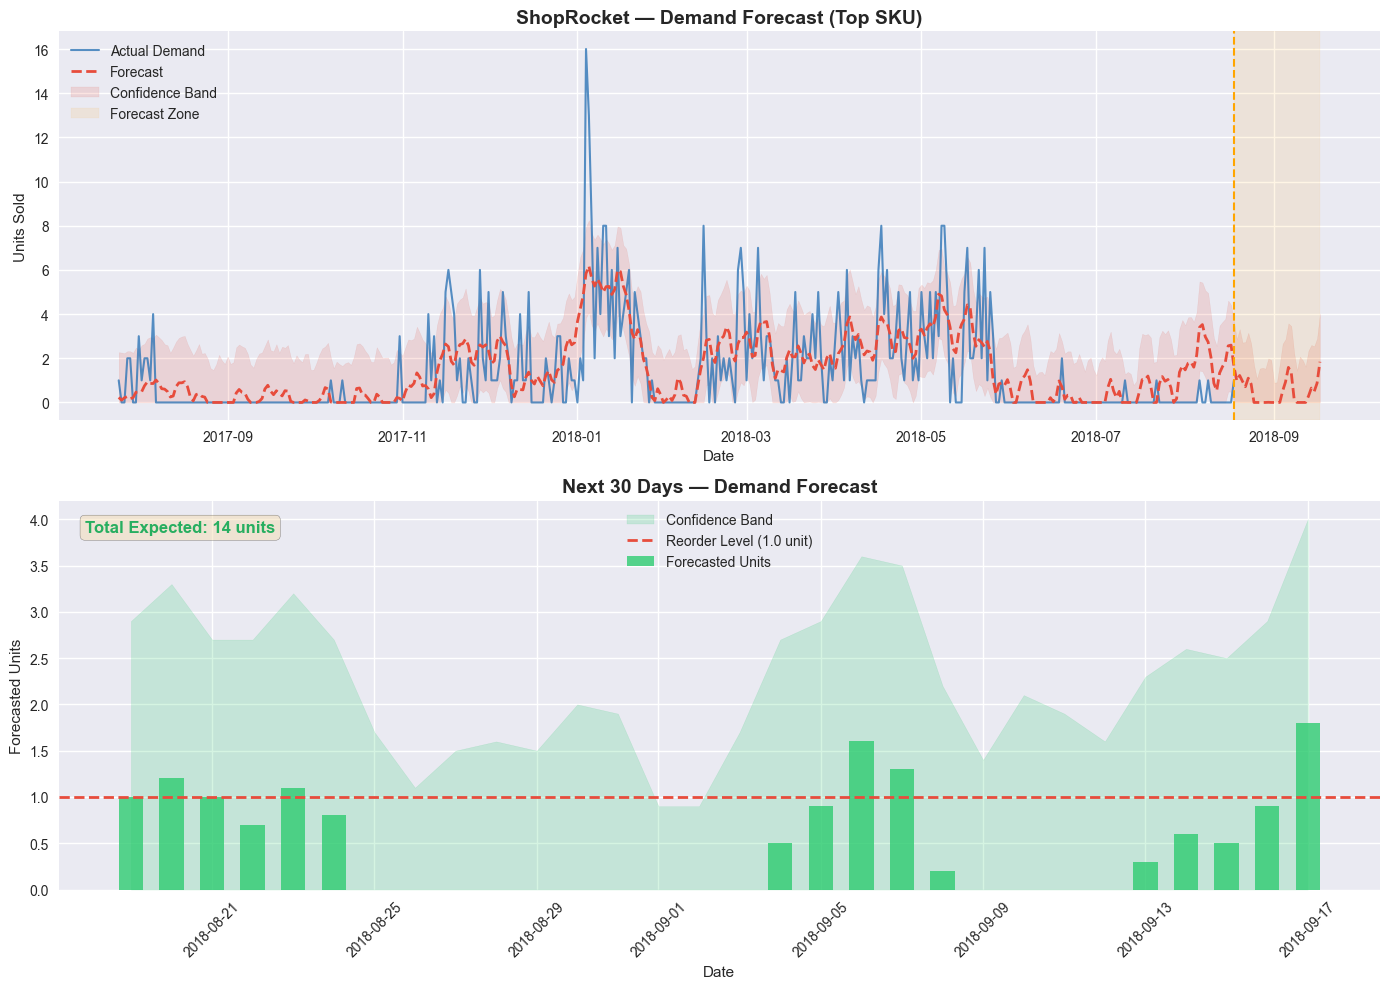

✅ Forecast chart saved!


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Top Chart — Full History + Forecast ───────────────
# Actual data
axes[0].plot(sku_df['ds'], sku_df['y'],
             color='#2E75B6', linewidth=1.5,
             label='Actual Demand', alpha=0.8)

# Forecast line
axes[0].plot(forecast['ds'], forecast['yhat'].clip(lower=0),
             color='#e74c3c', linewidth=2,
             label='Forecast', linestyle='--')

# Confidence band
axes[0].fill_between(forecast['ds'],
                     forecast['yhat_lower'].clip(lower=0),
                     forecast['yhat_upper'].clip(lower=0),
                     alpha=0.15, color='#e74c3c',
                     label='Confidence Band')

# Future zone highlight
axes[0].axvspan(last_date, future['ds'].max(),
                alpha=0.1, color='orange',
                label='Forecast Zone')

axes[0].axvline(x=last_date, color='orange',
                linestyle='--', linewidth=1.5)

axes[0].set_title('ShopRocket — Demand Forecast (Top SKU)',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Units Sold')
axes[0].legend(loc='upper left')

# ── Bottom Chart — Next 30 Days Only ──────────────────
axes[1].bar(future_only['ds'], future_only['yhat'],
            color='#2ecc71', alpha=0.8,
            label='Forecasted Units', width=0.6)

axes[1].fill_between(future_only['ds'],
                     future_only['yhat_lower'],
                     future_only['yhat_upper'],
                     alpha=0.2, color='#2ecc71',
                     label='Confidence Band')

# Reorder line — minimum stock level
reorder_level = 1.0
axes[1].axhline(y=reorder_level, color='#e74c3c',
                linestyle='--', linewidth=2,
                label=f'Reorder Level ({reorder_level} unit)')

axes[1].set_title('Next 30 Days — Demand Forecast',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Forecasted Units')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# Total forecasted units
total_forecast = future_only['yhat'].sum()
axes[1].text(0.02, 0.95,
             f'Total Expected: {total_forecast:.0f} units',
             transform=axes[1].transAxes,
             fontsize=12, fontweight='bold',
             color='#27ae60',
             verticalalignment='top',
             bbox=dict(boxstyle='round', 
                      facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('C:/Users/Sadique/OneDrive/Desktop/ShopRocket-ops-Analytics/reports/chart_07_demand_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Forecast chart saved!")